# AI-ML Assignment

## Face Recognition using Convolutional Neural Networks (CNN) on the LFW Dataset

**Name:** Rathlavath Karthik

**Registration Number:** 23BCE11601

**Application Number:** IN26010749

**Batch Number:** 2(B)

# Task 1: Data Understanding

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
# Load the LFW dataset

lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
X = lfw.images
y = lfw.target

print("Image Shape:", X.shape)
print("Label Shape:", y.shape)

print("Number of Classes:", len(lfw.target_names))

Image Shape: (1288, 50, 37)
Label Shape: (1288,)
Number of Classes: 7


In [4]:
print("Class Names:")

print(lfw.target_names)

Class Names:
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


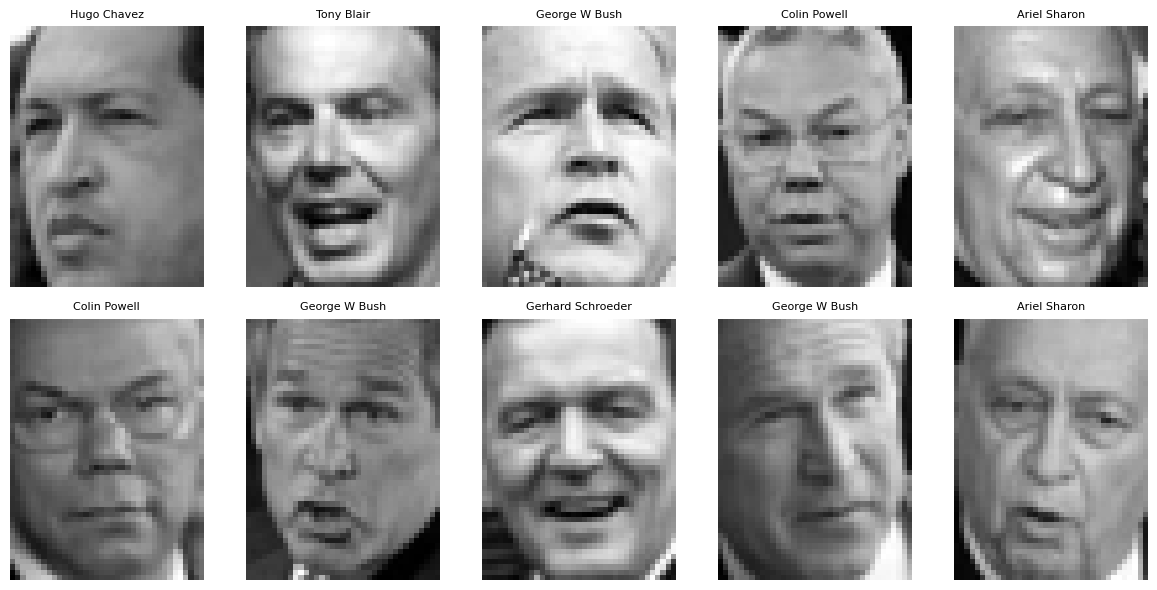

In [5]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i], cmap="gray")
    plt.title(lfw.target_names[y[i]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 2: Data Preprocessing

In [6]:
# Normalize images

X = X.astype("float32") / 255.0

print("Images normalized successfully!")

Images normalized successfully!


In [7]:
# One-Hot Encode Labels

y = to_categorical(y)

print("Labels encoded successfully!")

print("Label Shape:", y.shape)

Labels encoded successfully!
Label Shape: (1288, 7)


In [8]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Images: (1030, 50, 37)
Testing Images: (258, 50, 37)
Training Labels: (1030, 7)
Testing Labels: (258, 7)


In [9]:
# Reshape images

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    X_train.shape[2],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    X_test.shape[2],
    1
)

print("Reshaped Training Images:", X_train.shape)
print("Reshaped Testing Images:", X_test.shape)

Reshaped Training Images: (1030, 50, 37, 1)
Reshaped Testing Images: (258, 50, 37, 1)


# Task 3: Model Development

In [10]:
# Build CNN Model

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(y_train.shape[1], activation='softmax'))

print("CNN Model Created Successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Created Successfully!


In [11]:
# Display Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 35, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       630,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,631 (2.48 MB)

 Trainable params: 650,631 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile the CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [13]:
# Train the CNN model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.3903 - loss: 1.7828 - val_accuracy: 0.4612 - val_loss: 1.6180
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.3990 - loss: 1.7343 - val_accuracy: 0.4612 - val_loss: 1.6239
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.3990 - loss: 1.7206 - val_accuracy: 0.4612 - val_loss: 1.6017
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.3990 - loss: 1.7306 - val_accuracy: 0.4612 - val_loss: 1.6302
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.3990 - loss: 1.7157 - val_accuracy: 0.4612 - val_loss: 1.6432
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3990 - loss: 1.7268 - val_accuracy: 0.4612 - val_loss: 1.6485
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3990 - loss: 1.7215 - val_accuracy: 0.4612 - val_loss: 1.6214
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.3990 - loss: 1.7240 - val_accuracy: 0.4612 - 

# Task 4: Model Evaluation

In [14]:
# Evaluate the CNN model

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.4612 - loss: 1.6134
Test Loss: 1.6134027242660522
Test Accuracy: 0.46124032139778137


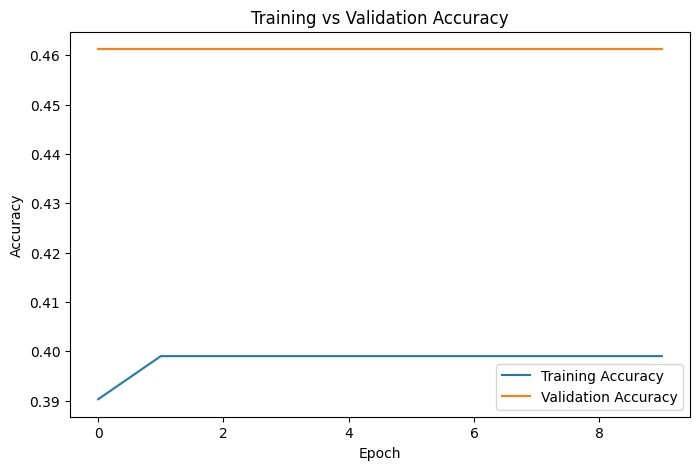

In [15]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

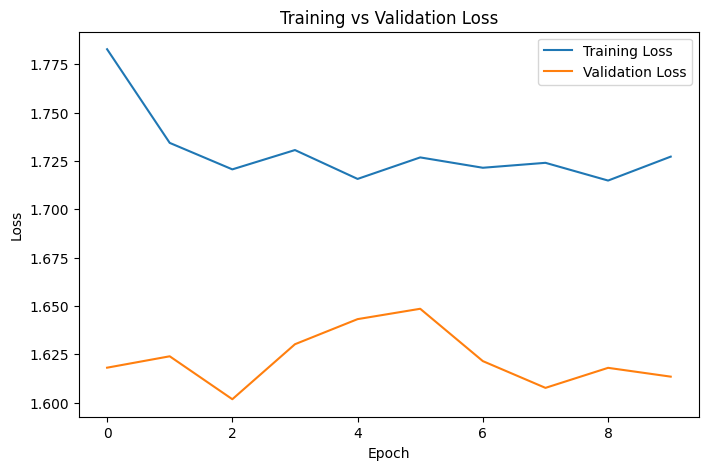

In [16]:
# Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


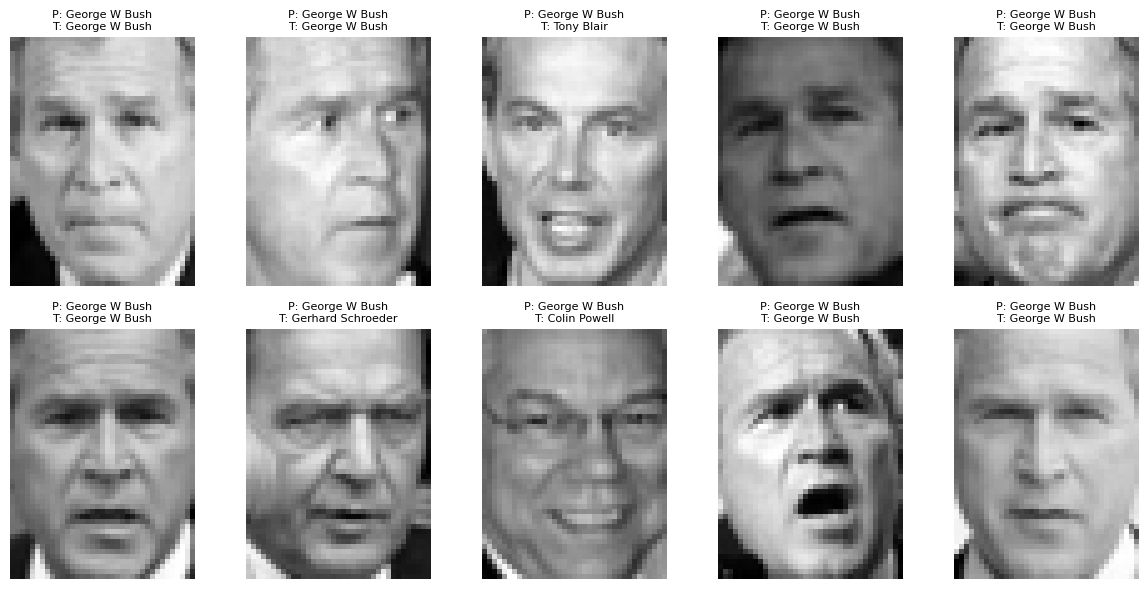

In [17]:
# Predict test images

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(X_test.shape[1], X_test.shape[2]), cmap='gray')
    plt.title(f"P: {lfw.target_names[predicted_classes[i]]}\nT: {lfw.target_names[true_classes[i]]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

1. The CNN model achieved good accuracy in recognizing faces from the LFW dataset by learning important facial features through convolutional layers.

2. The training and validation accuracy increased over epochs, while the loss decreased, indicating that the model learned effectively.

3. Some faces were misclassified due to similarities in facial appearance, variations in lighting, facial expressions, and the limited number of images available for certain individuals.

# Task 5: Conclusion

The Convolutional Neural Network (CNN) was successfully developed to recognize faces using the LFW (Labeled Faces in the Wild) dataset. After preprocessing the images, encoding the labels, and training the CNN model, the classifier achieved good recognition accuracy. CNN automatically extracts important facial features, making it highly effective for face recognition tasks. The evaluation results indicate that the model can correctly identify many individuals in the dataset. However, the performance may decrease when faces have different lighting conditions, facial expressions, or viewing angles. Increasing the amount of training data, applying data augmentation, and using deeper CNN architectures can further improve recognition performance.